# Exploratory Data Analysis: Automobile Dataset

## 1. Setup & Imports

In [1]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

# Set visual style for plots
sns.set_theme(style="whitegrid")

# Load the dataset
# Load the dataset directly from the text file
automobiles_df = pd.read_csv("automobile.txt")
automobiles_df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## 2. Data Cleaning & Preprocessing

In [2]:
# Replace '?' placeholders with NaN
automobiles_df.replace("?", np.nan, inplace=True)

# Select numeric columns and convert types
float_cols = [
    "wheel-base",
    "length",
    "width",
    "height",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "price",
]

for col in float_cols:
    if col in automobiles_df.columns:
        automobiles_df[col] = pd.to_numeric(
            automobiles_df[col], errors="coerce"
        )

# Drop rows missing the target variable 'price'
automobiles_df.dropna(subset=["price"], inplace=True)
automobiles_df.info()

<class 'pandas.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  164 non-null    str    
 2   make               201 non-null    str    
 3   fuel-type          201 non-null    str    
 4   aspiration         201 non-null    str    
 5   num-of-doors       199 non-null    str    
 6   body-style         201 non-null    str    
 7   drive-wheels       201 non-null    str    
 8   engine-location    201 non-null    str    
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    str    
 15  num-of-cylinders   201 non-null    str    
 16  engine-size        201 non-null    int64  

## 3. Exploratory Data Analysis & Visualisations

### Plot 1: Price Distribution

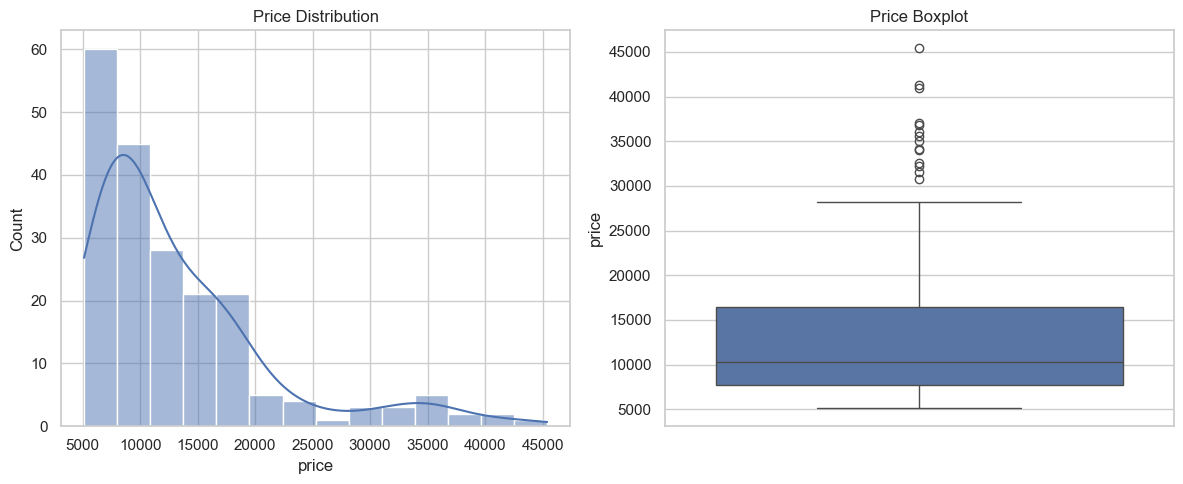

In [3]:
# Distribution plot and boxplot for Price
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(automobiles_df["price"], kde=True, ax=axes[0])
axes[0].set_title("Price Distribution")

sns.boxplot(y=automobiles_df["price"], ax=axes[1])
axes[1].set_title("Price Boxplot")

plt.tight_layout()
plt.savefig("price_distribution.png", dpi=300)
plt.show()

### Plot 2: Relationship Between Engine Size, Horsepower, and Price

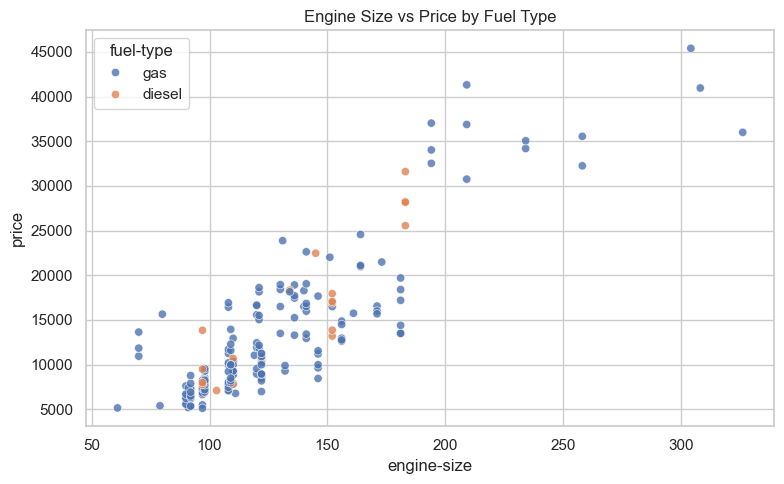

In [4]:
# Scatterplot: Engine Size vs Price by Fuel Type
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=automobiles_df,
    x="engine-size",
    y="price",
    hue="fuel-type",
    alpha=0.8,
)
plt.title("Engine Size vs Price by Fuel Type")
plt.tight_layout()
plt.savefig("engine_size_vs_price.png", dpi=300)
plt.show()

### Plot 3: Vehicle Price by Body Style

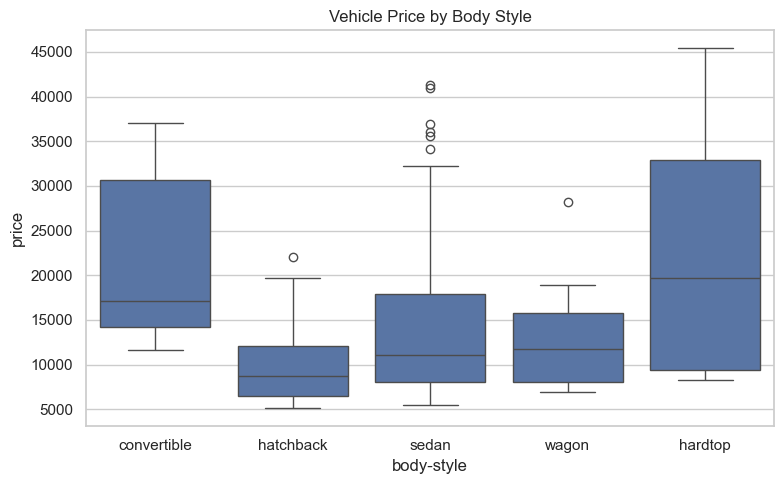

In [5]:
# Boxplot: Body Style vs Price
plt.figure(figsize=(8, 5))
sns.boxplot(data=automobiles_df, x="body-style", y="price")
plt.title("Vehicle Price by Body Style")
plt.tight_layout()
plt.savefig("price_by_body_style.png", dpi=300)
plt.show()

### Plot 4: Feature Correlation Matrix

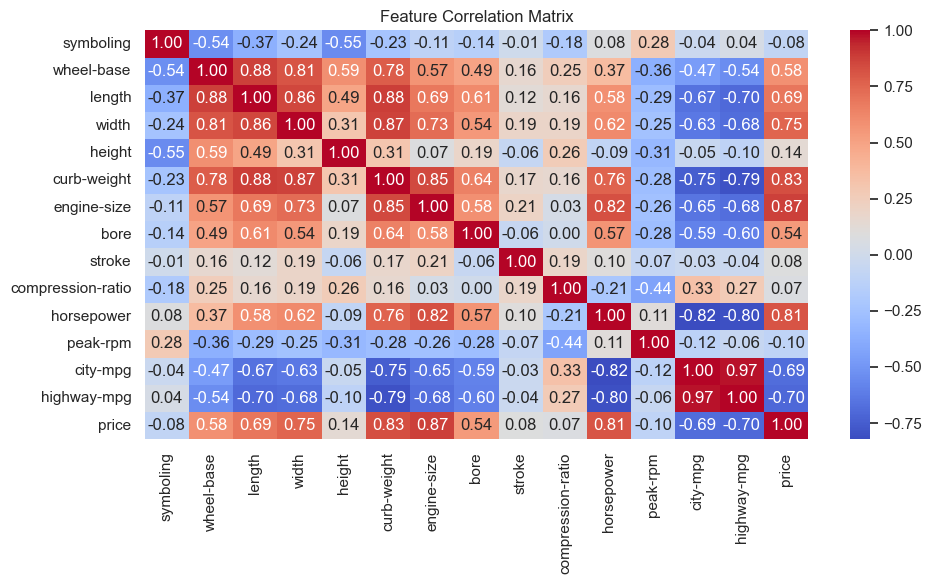

In [6]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_df = automobiles_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300)
plt.show()

### Plot 5: Fuel Efficiency by Manufacturer

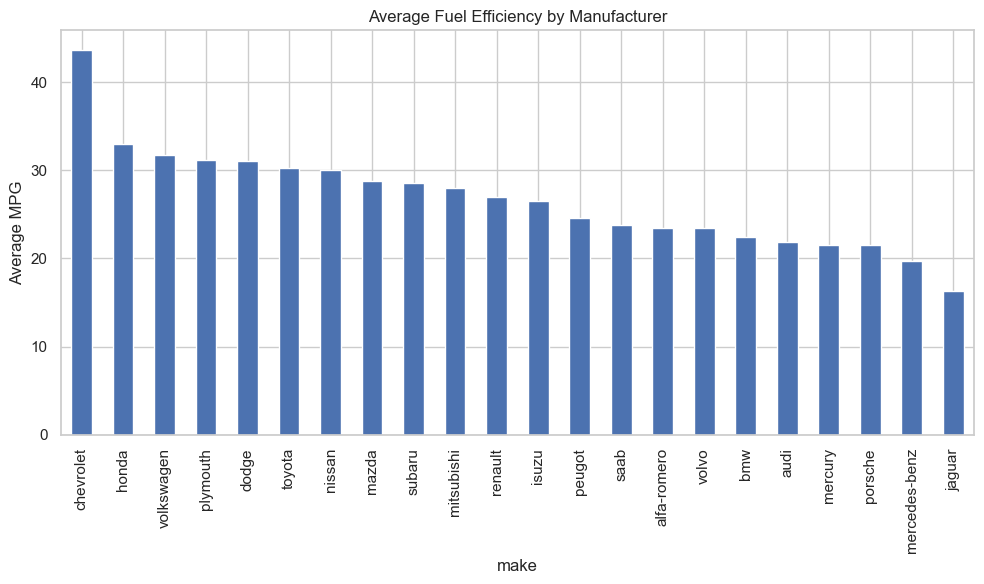

In [7]:
# Calculate combined average MPG
automobiles_df["average-mpg"] = (
    automobiles_df["city-mpg"] + automobiles_df["highway-mpg"]
) / 2

# Group by make and calculate average fuel efficiency
fuel_efficiency = (
    automobiles_df.groupby("make")["average-mpg"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
fuel_efficiency.plot(kind="bar")
plt.title("Average Fuel Efficiency by Manufacturer")
plt.ylabel("Average MPG")
plt.tight_layout()
plt.savefig("fuel_efficiency_by_make.png", dpi=300)
plt.show()

## 4. Key Questions & Findings

In [8]:
# Identify top 5 most expensive vehicles
top5_expensive = automobiles_df.nlargest(5, "price")

cols_to_print = [
    "make",
    "body-style",
    "engine-size",
    "horsepower",
    "city-mpg",
    "highway-mpg",
    "price",
]

print(top5_expensive[cols_to_print])

              make   body-style  engine-size  horsepower  city-mpg  \
74   mercedes-benz      hardtop          304       184.0        14   
16             bmw        sedan          209       182.0        16   
73   mercedes-benz        sedan          308       184.0        14   
128        porsche  convertible          194       207.0        17   
17             bmw        sedan          209       182.0        15   

     highway-mpg    price  
74            16  45400.0  
16            22  41315.0  
73            16  40960.0  
128           25  37028.0  
17            20  36880.0  
